# Data Workflow: What features determine the price of an Airbnb rental?

This notebook is organized by the tasks in the project instructions: 
- **Task 1:** dataset 
- **Task 3:** notebook setup 
- **Task 4:** import & load 
- **Task 5:** cleaning 
- **Task 6:** EDA 
- **Task 7:** visualizations 
- **Task 8:** summary 

Task that are not in the scope of this notebook:
- **Task 1:** GitHub 
- **Task 9:** README 
- **Task 10:** module_summary.pdf.

---

## Task 1 — Choose Your Dataset

**Dataset chosen:** [NYC Airbnb Listings (pricing and listing characteristics)](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data) — New York City listings from the Inside Airbnb project. The dataset meets project requirements (200+ rows, 5+ columns, CSV, academic use).

---

## Task 3 — Set Up Your Notebook

- **Your name:** Sebastian Obando Morales
- **Dataset:** NYC Airbnb Listings (link above)
- **Project description:** This notebook implements a complete data workflow for exploring NYC Airbnb listing data. We load and clean the data, run exploratory analysis to find features that influence price, and produce visualizations to support insights. The goal is to identify which features are most relevant to listing price and to practice reproducible EDA suitable as a foundation for future modeling.

In [1]:
# --- Task 4 — Import Libraries and Load Your Dataset ---
# Required libraries (project instructions)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datetime import datetime
from sklearn.linear_model import LinearRegression as LinReg
from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score

# Optional: folium for interactive maps (not required for notebook to run)
import folium
from folium.plugins import HeatMap


%matplotlib inline
sns.set_theme()

## Task 4 — Import Libraries and Load Your Dataset (continued)

Load the dataset and display the first rows to confirm it loaded correctly.

In [2]:
# Load dataset: place airbnb_nyc.csv in the same folder as this notebook (Task 1)
df = pd.read_csv('data/airbnb_nyc.csv', delimiter=',')
listings = df  # used as main variable in rest of notebook
print("Shape:", listings.shape)
listings.head()

Shape: (30179, 81)


,id,name,summary,description,experiences_offered,neighborhood_overview,transit,house_rules,host_id,host_since,...,hot_tub_sauna_or_pool,internet,long_term_stays,pets_allowed,private_entrance,secure,self_check_in,smoking_allowed,accessible,event_suitable
0,2539,Clean & quiet apt home by the park,Renovated apt home in elevator building.,Renovated apt home in elevator building. Spaci...,none,Close to Prospect Park and Historic Ditmas Park,Very close to F and G trains and Express bus i...,-The security and comfort of all our guests is...,2787,39698.0,...,-1,1,1,-1,-1,1,1,-1,1,1
1,3647,THE VILLAGE OF HARLEM....NEW YORK !,NaN,WELCOME TO OUR INTERNATIONAL URBAN COMMUNITY T...,none,NaN,NaN,Upon arrival please have a legibile copy of yo...,4632,39777.0,...,-1,1,-1,-1,-1,-1,-1,-1,-1,-1
2,7750,Huge 2 BR Upper East Cental Park,NaN,Large Furnished 2BR one block to Central Park...,none,NaN,NaN,NaN,17985,39953.0,...,-1,1,-1,1,-1,-1,-1,-1,-1,-1
3,8505,Sunny Bedroom Across Prospect Park,Just renovated sun drenched bedroom in a quiet...,Just renovated sun drenched bedroom in a quiet...,none,Quiet and beautiful Windsor Terrace. The apart...,Ten minutes walk to the 15th sheet F&G train s...,- No shoes in the house - Quiet hours after 11...,25326,40006.0,...,-1,1,-1,-1,-1,-1,-1,-1,-1,-1
4,8700,Magnifique Suite au N de Manhattan - vue Cloitres,Suite de 20 m2 a 5 min des 2 lignes de metro a...,Suite de 20 m2 a 5 min des 2 lignes de metro a...,none,NaN,Metro 1 et A,NaN,26394,40014.0,...,-1,1,-1,-1,-1,-1,-1,-1,-1,-1


Let's also look at the columns of the dataset:

In [3]:
listings.columns 

Index(['id', 'name', 'summary', 'description', 'experiences_offered',
       'neighborhood_overview', 'transit', 'house_rules', 'host_id',
       'host_since', 'host_response_time', 'host_response_rate',
       'host_is_superhost', 'host_listings_count', 'host_identity_verified',
       'street', 'neighbourhood', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'bed_type', 'amenities', 'price', 'guests_included', 'extra_people',
       'minimum_nights', 'calendar_updated', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'number_of_reviews', 'number_of_reviews_ltm',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'instant_bookable', 'cancellation_policy',
       'calculated_host_listings_count',


In [4]:
# We display the basic listings data.
pd.options.display.max_columns = 100
listings.head(3)

,id,name,summary,description,experiences_offered,neighborhood_overview,transit,house_rules,host_id,host_since,host_response_time,host_response_rate,host_is_superhost,host_listings_count,host_identity_verified,street,neighbourhood,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,bed_type,amenities,price,guests_included,extra_people,minimum_nights,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,cancellation_policy,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,check_in_24h,air_conditioning,high_end_electronics,bbq,balcony,nature_and_views,bed_linen,breakfast,tv,coffee_machine,cooking_basics,white_goods,elevator,gym,child_friendly,parking,outdoor_space,host_greeting,hot_tub_sauna_or_pool,internet,long_term_stays,pets_allowed,private_entrance,secure,self_check_in,smoking_allowed,accessible,event_suitable
0,2539,Clean & quiet apt home by the park,Renovated apt home in elevator building.,Renovated apt home in elevator building. Spaci...,none,Close to Prospect Park and Historic Ditmas Park,Very close to F and G trains and Express bus i...,-The security and comfort of all our guests is...,2787,39698.0,within an hour,1.0,0.0,6.0,1.0,"Brooklyn , NY, United States",Brooklyn,40.64749,-73.97237,Apartment,Private room,2,1.0,1,1,Real Bed,"{TV,""Cable TV"",Internet,Wifi,""Wheelchair acces...",149,1,35,1,3 weeks ago,1,30,60,90,365,9,2,98.0,10.0,10.0,10.0,10.0,10.0,10.0,0,moderate,6,0,5,1,0.21,1,-1,-1,-1,-1,-1,1,-1,1,1,1,1,1,-1,-1,1,-1,-1,-1,1,1,-1,-1,1,1,-1,1,1
1,3647,THE VILLAGE OF HARLEM....NEW YORK !,NaN,WELCOME TO OUR INTERNATIONAL URBAN COMMUNITY T...,none,NaN,NaN,Upon arrival please have a legibile copy of yo...,4632,39777.0,within a day,1.0,0.0,1.0,1.0,"New York, NY, United States",Harlem,40.80902,-73.94190,Apartment,Private room,2,1.0,1,1,Pull-out Sofa,"{""Cable TV"",Internet,Wifi,""Air conditioning"",K...",150,2,20,3,34 months ago,1,30,60,90,365,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,strict_14_with_grace_period,1,0,1,0,NaN,-1,1,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,-1
2,7750,Huge 2 BR Upper East Cental Park,NaN,Large Furnished 2BR one block to Central Park...,none,NaN,NaN,NaN,17985,39953.0,within a day,1.0,0.0,2.0,1.0,"New York, NY, United States",Harlem,40.79685,-73.94872,Apartment,Entire home/apt,4,1.0,2,2,Real Bed,"{TV,""Cable TV"",Internet,Wifi,""Air conditioning...",190,1,0,7,7 weeks ago,1,4,14,14,249,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,flexible,2,1,1,0,NaN,-1,1,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1,1,-1,1,-1,-1,-1,-1,-1,-1


## Task 5 — Build Your Data Cleaning Functions

Write at least two cleaning functions with docstrings and apply them to the dataset. Below we (1) remove extreme price outliers and (2) drop rows with missing values in key columns so the rest of the analysis uses a consistent, cleaned dataset.

In [5]:
def clean_price_outliers(df, price_col='price', upper_quantile=0.99):
    """
    Remove rows where price exceeds the given upper quantile.
    Reduces the influence of extreme listings (e.g. very high-end or data errors) on summaries and models.
    """
    threshold = df[price_col].quantile(upper_quantile)
    return df[df[price_col] <= threshold].copy()


def drop_missing_in_key_columns(df, columns=None):
    """
    Drop rows with missing values in key numeric columns used for analysis.
    Ensures correlation and plots use complete cases only.
    """
    if columns is None:
        columns = ['price', 'bedrooms', 'bathrooms', 'latitude', 'longitude']
    existing = [c for c in columns if c in df.columns]
    return df.dropna(subset=existing).copy()


# Apply cleaning: remove top 1% price outliers, then drop rows missing key fields
listings = clean_price_outliers(listings, upper_quantile=0.99)
listings = drop_missing_in_key_columns(listings)
print("Shape after cleaning:", listings.shape)
listings.head(3)

Shape after cleaning: (29884, 81)


,id,name,summary,description,experiences_offered,neighborhood_overview,transit,house_rules,host_id,host_since,host_response_time,host_response_rate,host_is_superhost,host_listings_count,host_identity_verified,street,neighbourhood,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,bed_type,amenities,price,guests_included,extra_people,minimum_nights,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,cancellation_policy,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,check_in_24h,air_conditioning,high_end_electronics,bbq,balcony,nature_and_views,bed_linen,breakfast,tv,coffee_machine,cooking_basics,white_goods,elevator,gym,child_friendly,parking,outdoor_space,host_greeting,hot_tub_sauna_or_pool,internet,long_term_stays,pets_allowed,private_entrance,secure,self_check_in,smoking_allowed,accessible,event_suitable
0,2539,Clean & quiet apt home by the park,Renovated apt home in elevator building.,Renovated apt home in elevator building. Spaci...,none,Close to Prospect Park and Historic Ditmas Park,Very close to F and G trains and Express bus i...,-The security and comfort of all our guests is...,2787,39698.0,within an hour,1.0,0.0,6.0,1.0,"Brooklyn , NY, United States",Brooklyn,40.64749,-73.97237,Apartment,Private room,2,1.0,1,1,Real Bed,"{TV,""Cable TV"",Internet,Wifi,""Wheelchair acces...",149,1,35,1,3 weeks ago,1,30,60,90,365,9,2,98.0,10.0,10.0,10.0,10.0,10.0,10.0,0,moderate,6,0,5,1,0.21,1,-1,-1,-1,-1,-1,1,-1,1,1,1,1,1,-1,-1,1,-1,-1,-1,1,1,-1,-1,1,1,-1,1,1
1,3647,THE VILLAGE OF HARLEM....NEW YORK !,NaN,WELCOME TO OUR INTERNATIONAL URBAN COMMUNITY T...,none,NaN,NaN,Upon arrival please have a legibile copy of yo...,4632,39777.0,within a day,1.0,0.0,1.0,1.0,"New York, NY, United States",Harlem,40.80902,-73.94190,Apartment,Private room,2,1.0,1,1,Pull-out Sofa,"{""Cable TV"",Internet,Wifi,""Air conditioning"",K...",150,2,20,3,34 months ago,1,30,60,90,365,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,strict_14_with_grace_period,1,0,1,0,NaN,-1,1,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,-1
2,7750,Huge 2 BR Upper East Cental Park,NaN,Large Furnished 2BR one block to Central Park...,none,NaN,NaN,NaN,17985,39953.0,within a day,1.0,0.0,2.0,1.0,"New York, NY, United States",Harlem,40.79685,-73.94872,Apartment,Entire home/apt,4,1.0,2,2,Real Bed,"{TV,""Cable TV"",Internet,Wifi,""Air conditioning...",190,1,0,7,7 weeks ago,1,4,14,14,249,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,flexible,2,1,1,0,NaN,-1,1,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1,1,-1,1,-1,-1,-1,-1,-1,-1


## Task 6 — Write an Exploratory Analysis Function

Create one or more exploratory analysis (EDA) functions (e.g. summary statistics, grouped/filtered views, correlation checks) and run them. Below we define a single EDA function that returns summary statistics and correlation with price, then run it on the cleaned data.

In [6]:
def run_eda_summary(df, target='price', numeric_cols=None):
    """
    Run exploratory analysis: summary statistics for numeric columns and correlation of all numeric columns with target.
    Returns (summary_df, correlation_series) for inspection.
    """
    if numeric_cols is None:
        numeric_cols = ['price', 'bedrooms', 'bathrooms', 'number_of_reviews', 'accommodates', 'latitude', 'longitude']
    numeric_cols = [c for c in numeric_cols if c in df.columns]
    summary = df[numeric_cols].describe()
    corr = df.corr(numeric_only=True)[target].sort_values(ascending=False)
    return summary, corr


summary_stats, price_corr = run_eda_summary(listings)
print("Summary statistics (key numeric columns):")
display(summary_stats)
print("\nCorrelation with price (descending):")
print(price_corr)

Summary statistics (key numeric columns):


,price,bedrooms,bathrooms,number_of_reviews,accommodates,latitude,longitude
count,29884.000000,29884.000000,29884.000000,29884.000000,29884.000000,29884.000000,29884.000000
mean,129.402657,1.254651,1.146684,4.466939,2.694552,40.728515,-73.952057
std,86.452419,0.595022,0.415591,5.268466,1.655057,0.054687,0.044166
min,0.000000,1.000000,0.500000,0.000000,1.000000,40.499790,-74.244420
25%,65.000000,1.000000,1.000000,0.000000,2.000000,40.690550,-73.981900
50%,100.000000,1.000000,1.000000,2.000000,2.000000,40.721230,-73.955050
75%,175.000000,1.000000,1.000000,7.000000,4.000000,40.762895,-73.936160
max,450.000000,11.000000,7.500000,20.000000,16.000000,40.913060,-73.716900



Correlation with price (descending):
price                                           1.000000
accommodates                                    0.565473
bedrooms                                        0.434811
beds                                            0.408096
guests_included                                 0.312040
                                                  ...   
smoking_allowed                                -0.056749
calculated_host_listings_count_shared_rooms    -0.106049
calculated_host_listings_count_private_rooms   -0.134665
longitude                                      -0.297443
has_availability                                     NaN
Name: price, Length: 65, dtype: float64


The following are details about some of the important columns here:

1. ```neighbourhood```:  which neighborhood the property is in
2. ```longitude```, ```latitude```: longitude and latitude
3. ```property_type```: type of property, such as apartment, condo etc.
4. ```bathrooms```: number of bathrooms
5. ```bedrooms```: number of bathrooms
6. ```price```:  price of the listing
7. ```number_of_reviews```: number of reviews given by customers who stayed there
8. ```parking```: 1 means there is parking available, -1 means there is not

For other categorical variables, such as ```outdoor_friendly```, ```gym```, etc., the 1,-1 should be interpreted similarly to ```parking``` as explained above.

---

## Task 7 — Create Three Visualizations

The project requires **at least three** visualizations using Matplotlib or Seaborn, each with a **title** and **labeled axes**. The three required visualizations appear in the next sections (marginal distributions, price vs. key variables, price vs. longitude by bedrooms). Additional plots in this notebook support further exploration.

### Plotting the marginal distributions of key quantities of interest

As you have seen in the Python cases, it is good to first develop an idea of how the values of a few key quantities of interest are distributed. We always start investigating by gaining an overhead view of various parameters in our data. Let's start by doing so for some numeric variables, such as ```price```, ```bedrooms```, ```bathrooms```, ```number_of_reviews```:

In [7]:
listings[['price','bedrooms','bathrooms','number_of_reviews']].describe()

,price,bedrooms,bathrooms,number_of_reviews
count,29884.000000,29884.000000,29884.000000,29884.000000
mean,129.402657,1.254651,1.146684,4.466939
std,86.452419,0.595022,0.415591,5.268466
min,0.000000,1.000000,0.500000,0.000000
25%,65.000000,1.000000,1.000000,0.000000
50%,100.000000,1.000000,1.000000,2.000000
75%,175.000000,1.000000,1.000000,7.000000
max,450.000000,11.000000,7.500000,20.000000


In [8]:
listings['price'].quantile([0.9,0.95,0.99])

0.90    250.0
0.95    300.0
0.99    400.0
Name: price, dtype: float64

In [9]:
listings['number_of_reviews'].describe()

count    29884.000000
mean         4.466939
std          5.268466
min          0.000000
25%          0.000000
50%          2.000000
75%          7.000000
max         20.000000
Name: number_of_reviews, dtype: float64

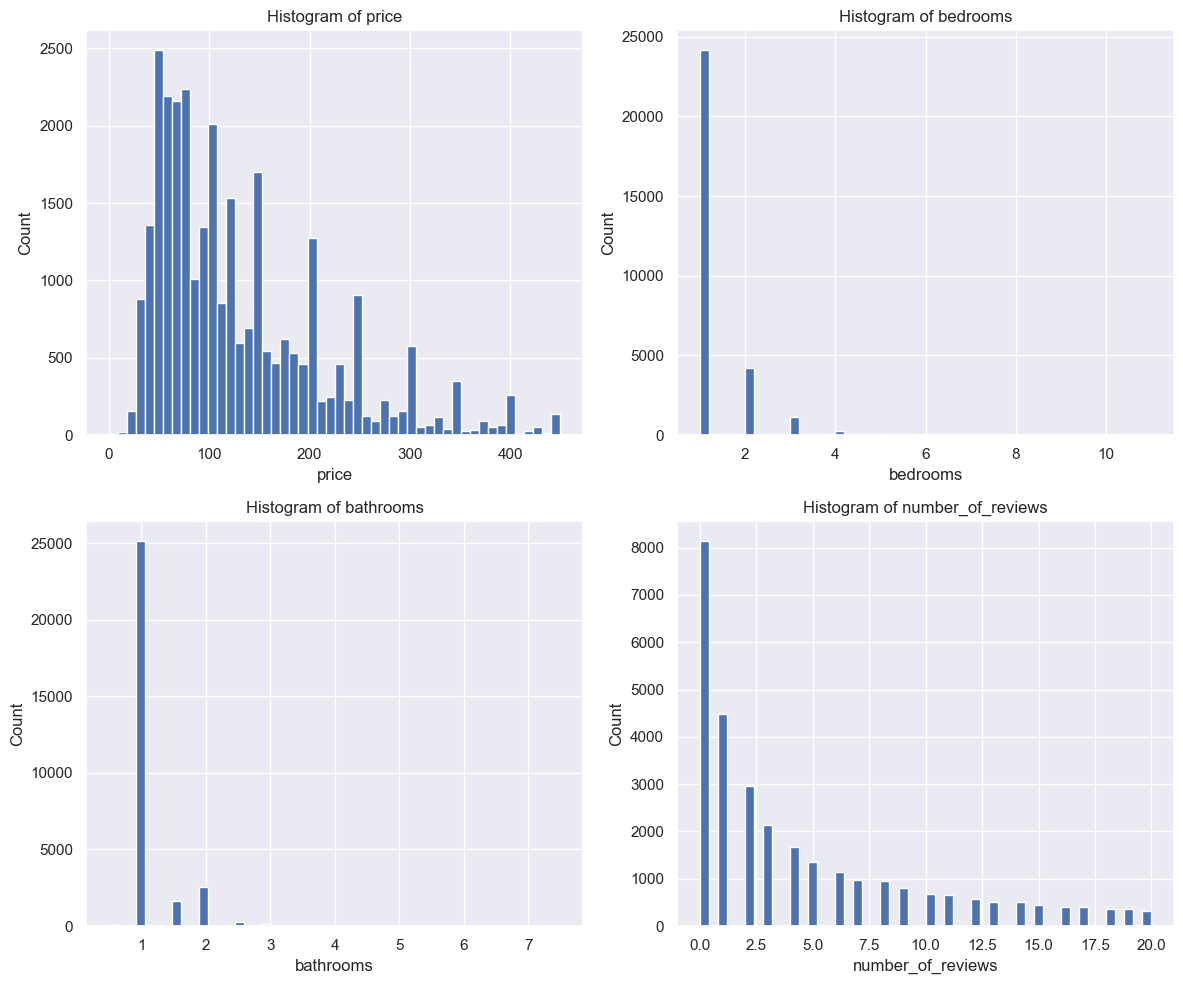

In [10]:
# Visualization 1: Marginal distributions (Task 7 – title and labeled axes)
plt.figure(figsize=(12,10))
vars_to_plot = ['price', 'bedrooms','bathrooms','number_of_reviews']
for i, var in enumerate(vars_to_plot):
    plt.subplot(2,2,i+1)
    plt.hist(listings[var],50)
    title_string = "Histogram of " + var
    plt.title(title_string)
    plt.xlabel(var)
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Another way to look at the histogram of number of bedrooms

Sometimes, it is better to look at a histogram which plots the <i>relative</i> percentages of values across categories:

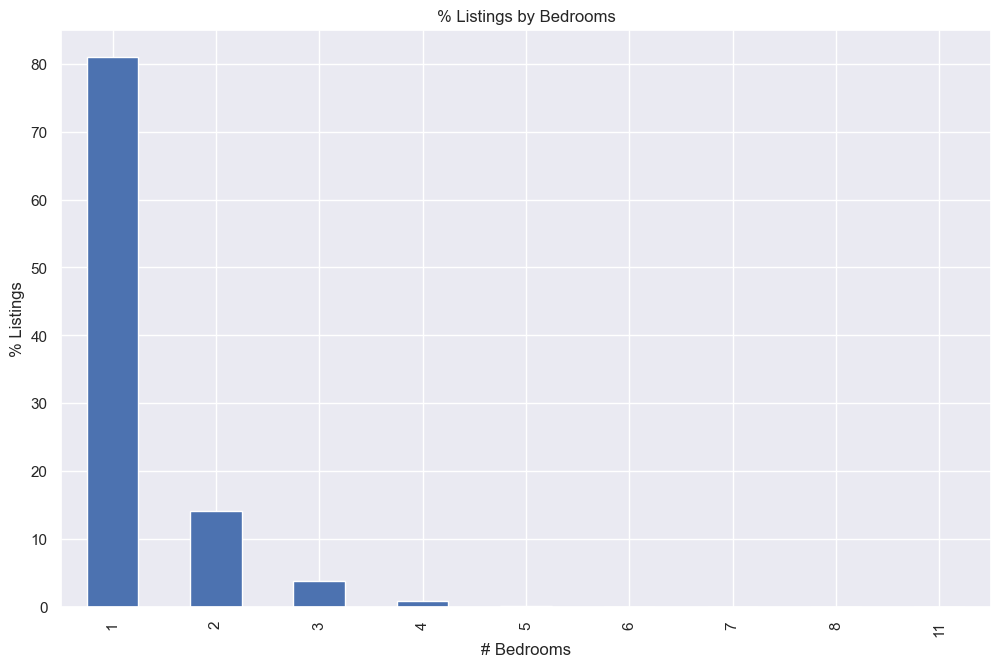

Percent of 1 Bedroom Listings: %80.91


In [ ]:
# Visualization 2: % Listings by Bedrooms
bedrooms_counts = Counter(listings.bedrooms)
tdf = pd.DataFrame.from_dict(bedrooms_counts, orient = 'index').sort_values(by = 0)
tdf = (tdf.iloc[-10:, :] / len(listings)) * 100

# Sort bedroom dataframe by number
tdf.sort_index(axis = 0, ascending = True, inplace = True)

# Plot percent of listings by bedroom number
ax = tdf.plot(kind = 'bar', figsize = (12, 7.5))
ax.set_xlabel("# Bedrooms")
ax.set_ylabel("% Listings")
ax.set_title('% Listings by Bedrooms')
ax.legend_.remove()

plt.show()

print("Percent of 1 Bedroom Listings: %{0:.2f}".format(tdf[0][1])) 
#The syntax 0:.2f denotes that we will print upto to decimal places
#Change it to %{0:.3f to see what happens}

## Inspecting price against variables of interest

Now that we have looked at the variables of interest in isolation, it makes sense to look at them in relation to price.

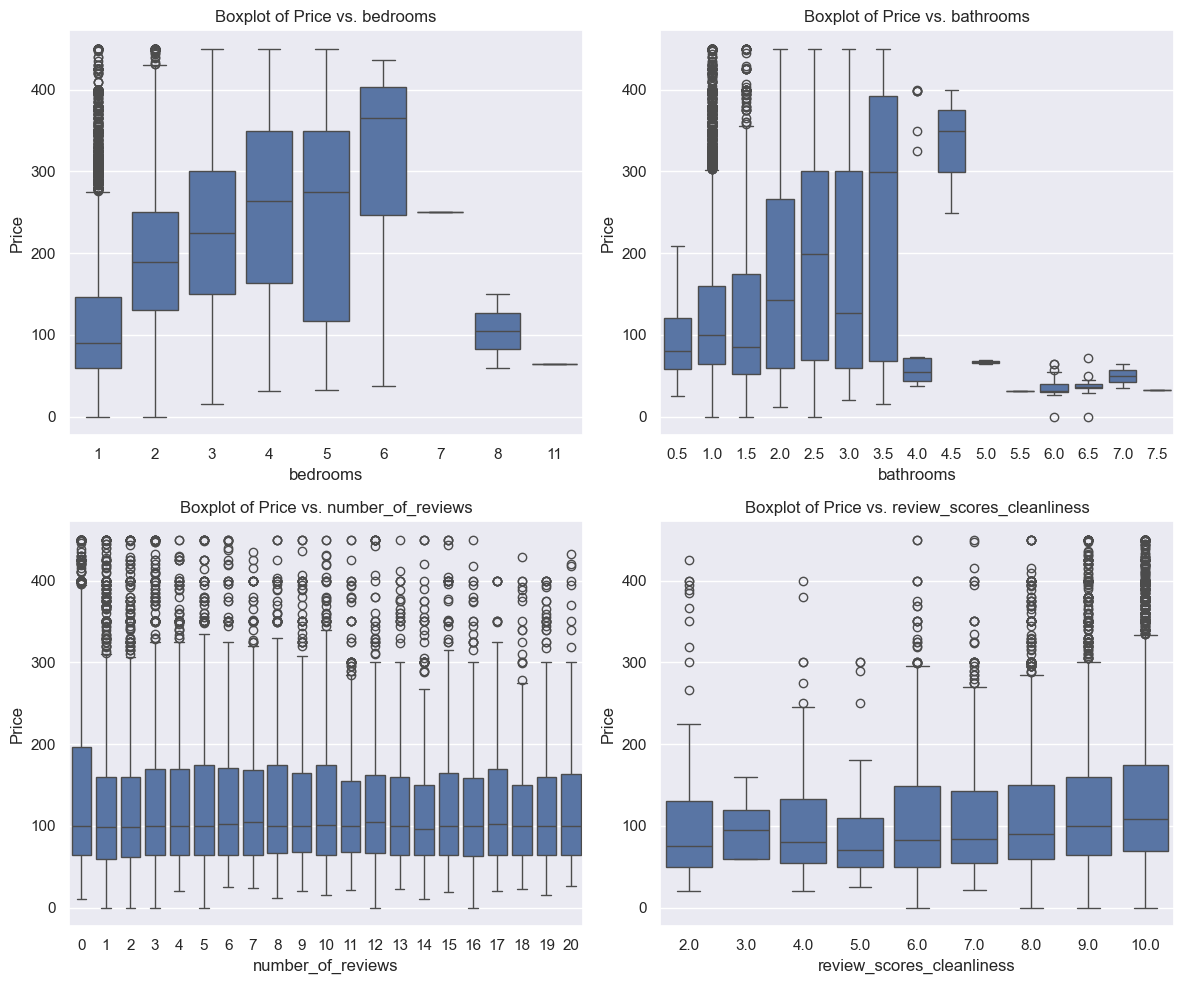

In [ ]:
# Visualization 3: Price vs key variables (Task 7 – title and labeled axes)
plt.figure(figsize=(12,10))
vars_to_plot = ['bedrooms','bathrooms','number_of_reviews','review_scores_cleanliness']
for i, var in enumerate(vars_to_plot):
    plt.subplot(2,2,i+1)
    sns.boxplot(x = var, y='price', data = listings)
    title_string = "Boxplot of Price vs. " + var
    plt.xlabel(var)
    plt.ylabel("Price")
    plt.title(title_string)
plt.tight_layout()
plt.show()


## Investigating correlations

Although plotting the relationship between price and a few other variables is a good first step, overall there are too many variables to individually plot and manually inspect. We need a more systematic method. How do we proceed? An easy way to get a quick overview of the key variables that affect the price is via <b>correlation</b>.

Let's look at the ```price``` vs. ```bedrooms``` plot again:

Text(0.5, 1.0, 'Boxplot of Price vs. Bedrooms')

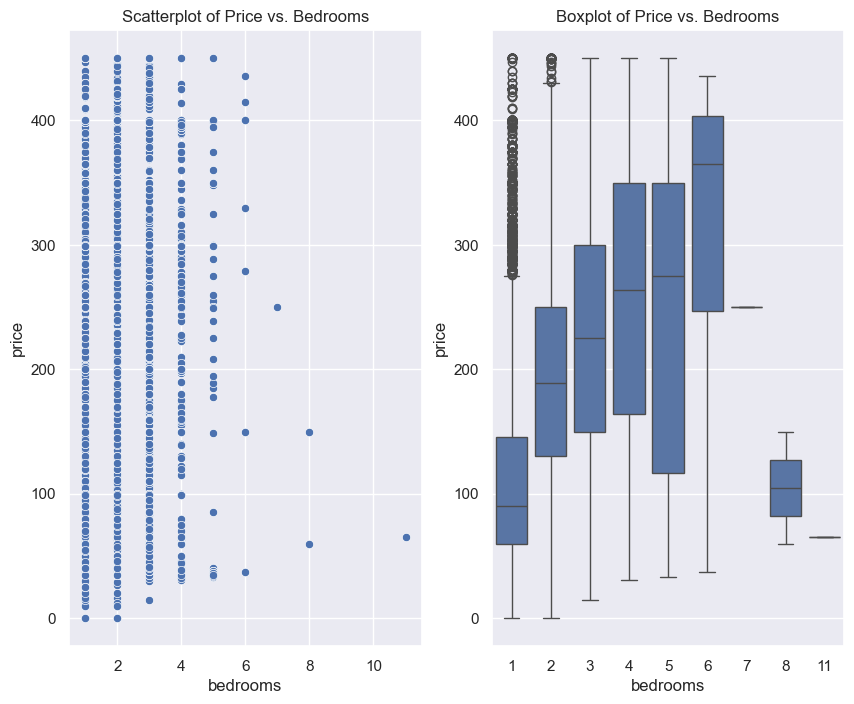

In [ ]:
# Visualization 5: Price vs bedrooms (Task 7 – title and labeled axes)
plt.figure(figsize=(10,8))
plt.subplot(121)
sns.scatterplot(x='bedrooms',y = 'price', data = listings)
plt.ylabel("price")
plt.title("Scatterplot of Price vs. Bedrooms")
plt.subplot(122)
sns.boxplot(x='bedrooms',y= 'price', data = listings)
plt.ylabel("price")
plt.title("Boxplot of Price vs. Bedrooms")

We see that as the number of bedrooms increases, the price on average increases. The quantity <b>correlation</b> is one way to capture this relationship. The correlation of two quantities is a measurement of how much they tend to increase together, measured on a scale going from -1 to 1. A positive correlation between price and number of bedrooms would indicate that higher-priced listings tend to have <i>more</i> bedrooms. Similarly, a negative correlation between price and number of bedrooms would indicate that higher-priced listings tend to have <i>fewer</i> bedrooms.  In our case, we can easily see that price is positively correlated with bedrooms.

Since correlation is just a single number summarizing an entire joint distribution, it can be misleading and does not eliminate the need to plot and visually inspect the key variables that it suggests are important. Nonetheless, it is quite helpful when quickly scanning for very strong relationships in the data and whittling down a much larger list of potential factors.

In [14]:
np.corrcoef(listings['price'],listings['bedrooms'])[0,1]

np.float64(0.43481127478322323)

The [correlation matrix](https://www.displayr.com/what-is-a-correlation-matrix/) then gives all of the pairwise correlations between all of the variables. We can get a quick overview of the key variables that affect the price by looking at its row in the correlation matrix.

In [15]:
# Create a correlation matrix
corr    = listings.corr(numeric_only=True)
pos_cor = corr['price'] >0
neg_cor = corr['price'] <0
corr['price'][pos_cor].sort_values(ascending = False)
#This prints out the coefficients that are positively correlated with price.

price                                          1.000000
accommodates                                   0.565473
bedrooms                                       0.434811
beds                                           0.408096
guests_included                                0.312040
tv                                             0.275815
elevator                                       0.232855
calculated_host_listings_count_entire_homes    0.222656
gym                                            0.216433
white_goods                                    0.212632
child_friendly                                 0.212065
host_listings_count                            0.201643
air_conditioning                               0.197614
calculated_host_listings_count                 0.186364
review_scores_location                         0.144619
private_entrance                               0.143915
bathrooms                                      0.131334
coffee_machine                                 0

In [16]:
corr['price'][neg_cor].sort_values()

longitude                                      -0.297443
calculated_host_listings_count_private_rooms   -0.134665
calculated_host_listings_count_shared_rooms    -0.106049
smoking_allowed                                -0.056749
host_greeting                                  -0.051878
number_of_reviews                              -0.026088
host_since                                     -0.020449
parking                                        -0.019204
host_is_superhost                              -0.017892
host_identity_verified                         -0.015515
number_of_reviews_ltm                          -0.012086
review_scores_value                            -0.006885
Name: price, dtype: float64

Many of these are unsurprising – for example, the largest correlations are with measures of size (```accommodates```, ```bedrooms```, ```beds```, etc.). Review scores are only slightly related to price. Looking at the location-related scores, we find that longitude is negatively related to price while latitude is not. This motivates us to plot them on a map (we will do this next).

We also notice a few correlations that seem a bit surprising. For example:

1. Parking is negatively correlated to price. This correlation with parking is very suspicious – why would parking be bad? I suspect that it is "spurious", caused by the fact that parking is more common in less expensive neighborhoods. Let's investigate this by looking at parking in a region-by-region manner.
2. Being a superhost is negatively correlated; we don't follow up on it here.
3. The total number of listings is positively correlated. This seems counterintuitive, as one would want large-scale listers to be able to rent more cheaply due to economies of scale.

We found quite a few variables that are reasonably correlated with price. We could continue our exploration by looking at each of these variables in turn, but we know that in real estate, location data is quite special, and so we will first explore how location affects the price in greater detail.

We will use the [folium](https://pypi.org/project/folium/) package. Make sure that you have installed the package (if not, do it now!). The following gives an interactive map for plotting the listings on a map of New York City:

In [17]:
folium_map = folium.Map(location=[40.738, -73.98],
                        zoom_start=13,
                        tiles="OpenStreetMap")
folium_map

In [18]:
folium_map = folium.Map(location=[40.738, -73.98],
                        zoom_start=13,
                        tiles="OpenStreetMap")
for i in range(0, min(1000, len(listings))):
    marker = folium.CircleMarker(location=[listings["latitude"].iloc[i], listings["longitude"].iloc[i]], radius=5, color="r", fill=True)
    marker.add_to(folium_map)
    
folium_map

### Using heatmaps to understand the price distribution with location

Next, we create a heatmap of the price of apartments in NYC. This will give us a sense of where the important locations are:

In [20]:
max_amount = float(listings['price'].max())
folium_hmap = folium.Map(location=[40.738, -73.98],
                        zoom_start=13,
                        tiles="OpenStreetMap")
hm_wide = HeatMap(list(zip(listings['latitude'], listings['longitude'], listings['price'])),
                    min_opacity=0.2, max_val=max_amount, radius=8, blur=6, max_zoom=15)
folium_hmap.add_child(hm_wide)
folium_hmap

C:\Users\sebas\AppData\Local\Temp\ipykernel_42024\3852315264.py:5: UserWarning: The `max_val` parameter is no longer necessary. The largest intensity is calculated automatically.
  hm_wide = HeatMap(list(zip(listings['latitude'], listings['longitude'], listings['price'])),


Manhattan and Brooklyn are very pricey; Queens is relatively less so. In general, things farther away from Manhattan and Brooklyn are cheaper.

The location does seem to be strongly related to price; however, the relationship doesn't seem to be close to linear. This suggests that, when we model price, we will need to incorporate location data and our method cannot be via a linear mapping.

### Longitude vs. Price

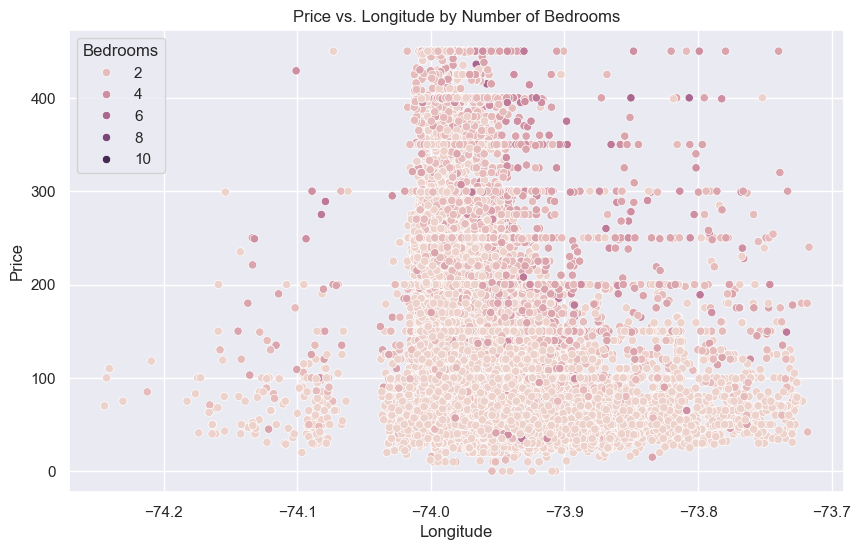

In [21]:
# Visualization 3: Price vs longitude by bedrooms (Task 7 – title and labeled axes)
plt.figure(figsize=(10,6))
sns.scatterplot(x=listings['longitude'], y=listings['price'], hue=listings['bedrooms'])
plt.xlabel("Longitude")
plt.ylabel("Price")
plt.title("Price vs. Longitude by Number of Bedrooms")
plt.legend(title="Bedrooms")
plt.show()

When looking at the list of correlations, ```parking``` stood out as having a surprisingly negative correlation with price. We've seen that location has a strong influence on price; let's see if it can help explain the negative correlation exhibited by ```parking```.

Plotting the first 1000 locations on the map where parking is available by blue color, and the first 1000 locations where parking is not available by red color:

In [22]:
lat_log_parking_yes = listings.loc[listings['parking']==1.0, ["latitude","longitude"]]
lat_log_parking_no = listings.loc[listings['parking']==-1.0, ["latitude","longitude"]]
folium_map = folium.Map(location=[40.738, -73.98], zoom_start=13, tiles="OpenStreetMap")
n_show = min(1000, len(lat_log_parking_yes), len(lat_log_parking_no))
for i in range(n_show):
    marker = folium.CircleMarker(location=[lat_log_parking_yes["latitude"].iloc[i], lat_log_parking_yes["longitude"].iloc[i]], radius=5, color="blue", fill=True)
    marker.add_to(folium_map)
for i in range(n_show):
    marker = folium.CircleMarker(location=[lat_log_parking_no["latitude"].iloc[i], lat_log_parking_no["longitude"].iloc[i]], radius=5, color="red", fill=True)
    marker.add_to(folium_map)
folium_map

## Interaction effects and iterative hypotheses

Now that we have explored some of the factors that are expected to affect price, let's focus on understanding the unexpected correlations, such as the negative correlation with parking. We start with the latter:

C:\Users\sebas\AppData\Local\Temp\ipykernel_2068\3359046116.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(listings.loc[listings['parking'] == 1,'price'],shade = True, label="Parking",color="g")
C:\Users\sebas\AppData\Local\Temp\ipykernel_2068\3359046116.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(listings.loc[listings['parking'] == -1,'price'],shade = True, label="No Parking",color="r")


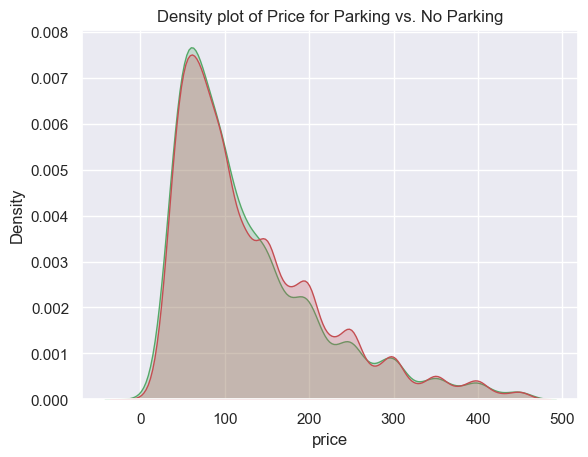

In [ ]:
# First, plot parking vs. non-parking prices.
sns.kdeplot(listings.loc[listings['parking'] == 1,'price'],shade = True, label="Parking",color="g")
sns.kdeplot(listings.loc[listings['parking'] == -1,'price'],shade = True, label="No Parking",color="r")
plt.title("Density plot of Price for Parking vs. No Parking");

We saw before that the correlation between price and parking is -0.019383. Since parking is desirable, we expect the price to increase with parking. When we see a pattern like this, we should suspect the existence of **interaction effects** that are complicating the parking vs. price relationship. Interaction effects are when the relationship between two variables is **conditional**, or depends on the value of a third, hidden variable.

### Correlations between price and neighborhood parking

Write code to make a dictionary in which the keys are the `neighbourhoods` in the dataset and the values are the correlation between price and parking for that neighborhood.

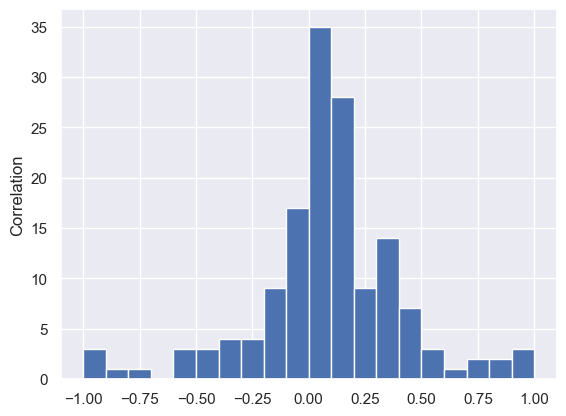

Average correlation:  0.08257037062741614


In [ ]:
neighbourhoods = listings.neighbourhood.unique()
cvec = list()
cvec = dict()

for x in neighbourhoods:
    temp = listings[listings['neighbourhood'] == x]
    cvec[x] = temp.corr(numeric_only=True)['price']['parking']


res = list(cvec.values())
res = [x for x in res if str(x) != 'nan']
res.sort()


plt.hist(res, bins=20)
plt.ylabel('Correlation')
plt.show()


print('Average correlation: ', sum(res)/len(res))
# print(cvec)

#print(list(cvec).sort())

*Our original correlation of about $-0.02$ was the correlation between price and parking <i>for all listings in NYC</i> – that is, the conditional correlation between price and parking <i> given that you are in NYC</i>. The number ```res['Brooklyn']``` is the correlation between price and parking <i>for all listings in Brooklyn</i> – that is, the conditional correlation between price and parking <i>given that you are in Brooklyn</i>. 

The histogram shows us that most of the conditional correlations within neighborhoods are positive, even though the correlation across all of NYC is negative. Roughly speaking, this means that the following are all occurring:

1. Within neighborhoods, parking is positively associated with price.
2. Different neighborhoods have very different typical prices (as we saw last section).
3. Parking tends to be concentrated in cheaper neighborhoods.

The correlation values of 1 and -1 are presumably due largely to neighborhoods with very few listings, and should essentially be ignored. Viewing the histogram, however, we can see that a clear majority of correlations are at least slightly positive, for an average correlation of 0.08.

If we plot this by neighborhood for a few neighborhoods, we can see this somewhat positive correlation of parking vs. no parking visually: 

C:\Users\sebas\AppData\Local\Temp\ipykernel_2068\3851747792.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(listings.loc[(listings['parking'] == 1) & (listings['neighbourhood'] == neigh),'price'],shade = True, label="Parking",color="g")
C:\Users\sebas\AppData\Local\Temp\ipykernel_2068\3851747792.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(listings.loc[(listings['parking'] == -1) & (listings['neighbourhood'] == neigh),'price'],shade = True, label="No Parking",color="r")
C:\Users\sebas\AppData\Local\Temp\ipykernel_2068\3851747792.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(listings.loc[(listings['parkin

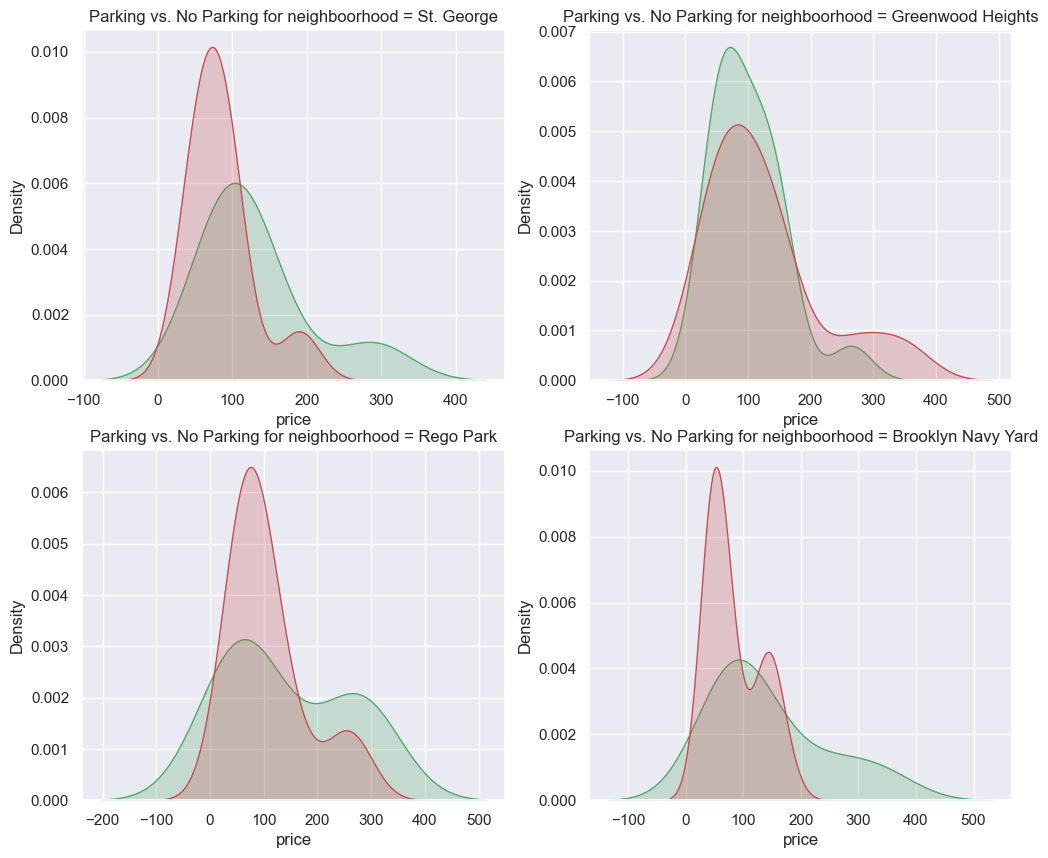

In [ ]:
plt.figure(figsize=(12,10))
neigh_to_look = ['St. George','Greenwood Heights','Rego Park','Brooklyn Navy Yard']
for i, neigh in enumerate(neigh_to_look):
 plt.subplot(2,2,i+1)
 sns.kdeplot(listings.loc[(listings['parking'] == 1) & (listings['neighbourhood'] == neigh),'price'],shade = True, label="Parking",color="g")
 sns.kdeplot(listings.loc[(listings['parking'] == -1) & (listings['neighbourhood'] == neigh),'price'],shade = True, label="No Parking",color="r")
 plt.title("Parking vs. No Parking for neighboorhood = " + str(neigh));

As we have seen, the existence of unexpected correlations should spur investigation into potential interaction effects, which lead to potentially interesting hypotheses. Thus, one good way of generating iterative hypotheses is to find and think about potential interaction effects.

## Finding more interactions: how does price vary by property type?

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31],
 [Text(0, 0, 'Apartment'),
  Text(1, 0, 'Condominium'),
  Text(2, 0, 'House'),
  Text(3, 0, 'Townhouse'),
  Text(4, 0, 'Boutique hotel'),
  Text(5, 0, 'Bed and breakfast'),
  Text(6, 0, 'Loft'),
  Text(7, 0, 'Treehouse'),
  Text(8, 0, 'Serviced apartment'),
  Text(9, 0, 'Earth house'),
  Text(10, 0, 'Aparthotel'),
  Text(11, 0, 'Other'),
  Text(12, 0, 'Guest suite'),
  Text(13, 0, 'Villa'),
  Text(14, 0, 'Hostel'),
  Text(15, 0, 'Cave'),
  Text(16, 0, 'Bungalow'),
  Text(17, 0, 'Houseboat'),
  Text(18, 0, 'Castle'),
  Text(19, 0, 'Cabin'),
  Text(20, 0, 'Resort'),
  Text(21, 0, 'Tiny house'),
  Text(22, 0, 'Guesthouse'),
  Text(23, 0, 'Hotel'),
  Text(24, 0, 'Tent'),
  Text(25, 0, 'Dome house'),
  Text(26, 0, 'Farm stay'),
  Text(27, 0, 'Casa particular (Cuba)'),
  Text(28, 0, 'Cottage'),
  Text(29, 0, 'Bo

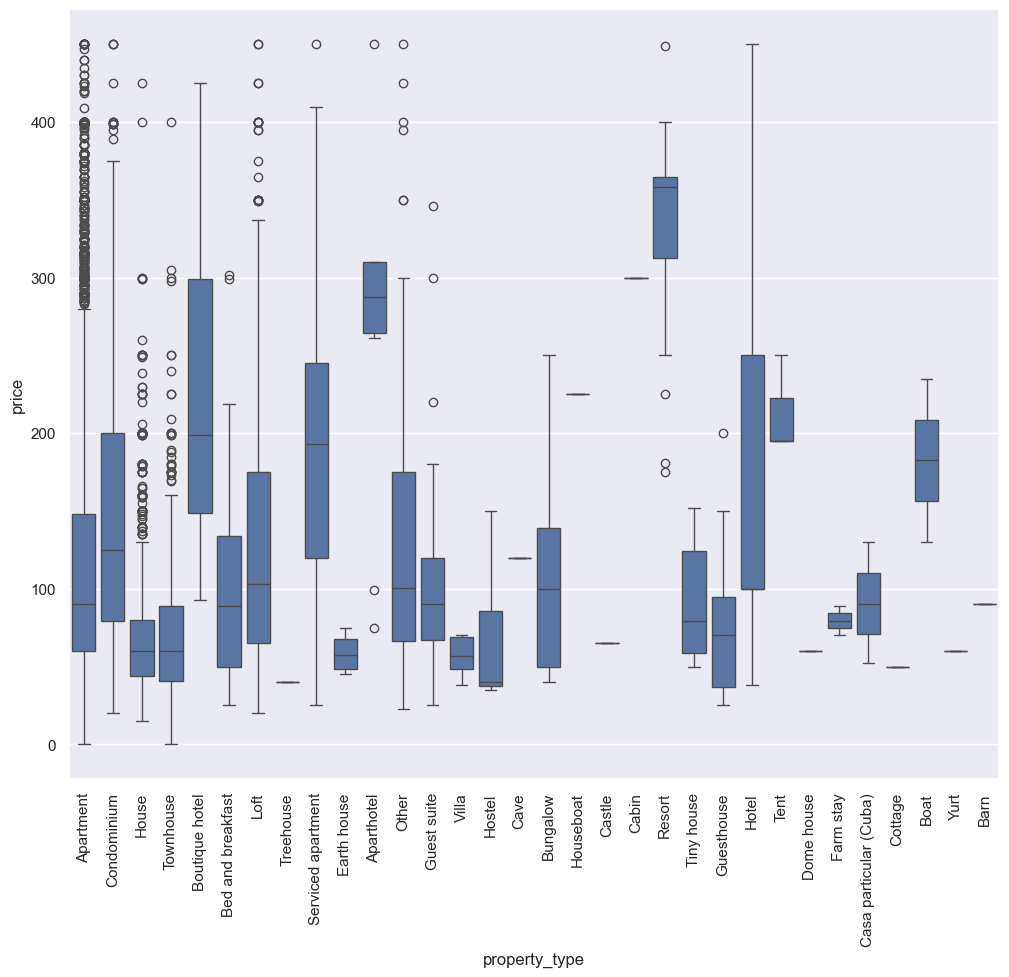

In [ ]:
plt.figure(figsize=(12,10)) 
sns.boxplot(y=listings.loc[listings['bedrooms']==1,'price'], x= listings.loc[listings['bedrooms']==1,'property_type'])
plt.xticks(rotation = 90)

There is significant variation in price according to the property type; a room in a house or a loft is the cheapest, while cabins, boutique hotels, and boats are very expensive! It is also interesting to see huge variations in hotel prices.

### Price vs. Property type plot for two bedroom listings.

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, 'Apartment'),
  Text(1, 0, 'Townhouse'),
  Text(2, 0, 'Condominium'),
  Text(3, 0, 'House'),
  Text(4, 0, 'Loft'),
  Text(5, 0, 'Cabin'),
  Text(6, 0, 'Serviced apartment'),
  Text(7, 0, 'Villa'),
  Text(8, 0, 'Guesthouse'),
  Text(9, 0, 'Bed and breakfast'),
  Text(10, 0, 'Guest suite'),
  Text(11, 0, 'Other'),
  Text(12, 0, 'Bungalow'),
  Text(13, 0, 'Boat'),
  Text(14, 0, 'Resort'),
  Text(15, 0, 'Boutique hotel'),
  Text(16, 0, 'Aparthotel'),
  Text(17, 0, 'Cottage'),
  Text(18, 0, 'Cave'),
  Text(19, 0, 'Camper/RV'),
  Text(20, 0, 'Houseboat'),
  Text(21, 0, 'Yurt')])

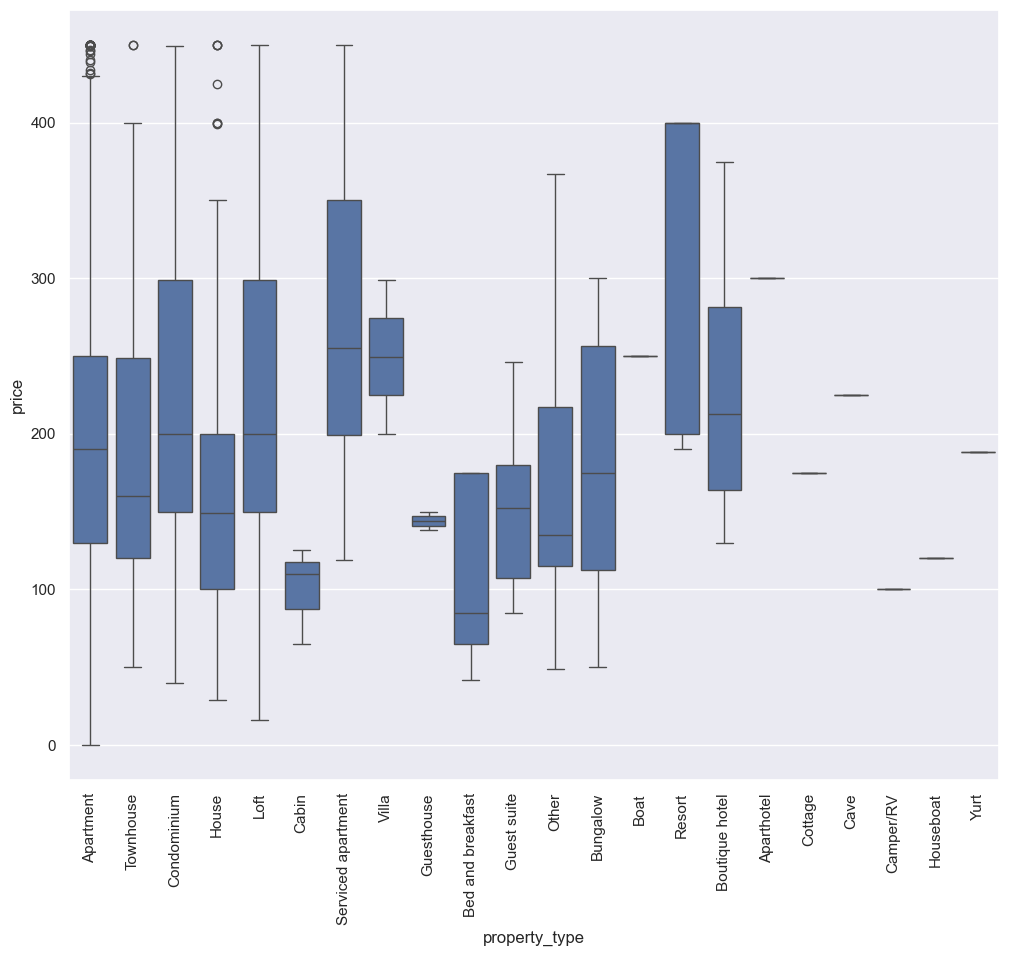

In [ ]:
plt.figure(figsize=(12,10)) 
sns.boxplot(y=listings.loc[listings['bedrooms']==2,'price'], x= listings.loc[listings['bedrooms']==2,'property_type'])
plt.xticks(rotation = 90)

## More hypothesis generation

So far, we have primarily been interested in understanding what factors influence the price of an existing listing. However, a natural question to ask is what you can do to increase the price of your own listing without spending too much money?

Looking through the list of correlations, two immediately stand out: 

| Object          | Correlation  | 
| :-------------  | :----------: | 
|  AC             | 0.18         | 
|  TV             | 0.26         | 

Some air conditioning is relatively cheap, and has a large correlation of 0.189. Televisions are very cheap, and have an enormous correlation of 0.26. This suggests that one of the best things I can do for a listing is run out and buy a TV if I don't have one – a 300 dollar TV might increase the value of a listing by 30 dollars per night!

Apartments with TVs are systematically better than those without – indeed, presence of a television is positively correlated with many other positive price signals, from the size of the listing (e.g. number of people it accommodates) to essentially all other amenities. Nevertheless, it is important to not quickly conclude everything simply based on correlations. We will discuss this much more carefully in a later class on causal inference.

## Exploring temporal effects: summer in Rio and winter in Moscow

We have seen that conditional plots can be a useful way to "correct" comparisons by taking into account interaction effects.

Time is a very common interaction effect that appears across lots of datasets. For Airbnb data, this is especially important, as Airbnb is often more expensive near holidays, and so reasonable price estimates must take this into account. In practice this is one of the most important corrections offered by Airbnb pricing consultancy firms, and corrections usually take advantage of data pooled from many somewhat similar cities. This is vital to achieving good corrections, but it is easy to make mistakes by failing to account for important city-to-city differences.

We begin by opening up the calendar data and counting (i) the number of rentals per day; and (ii) their total prices: 

In [ ]:
cal = pd.read_csv('data/scal.csv', delimiter=',')
cal.head()
# Count rentals and total price on each date.

,date,price,listing_id
0,2024-01-01,150,1
1,2024-01-02,150,1
2,2024-01-01,200,2
3,2024-01-02,220,2
4,2024-01-01,100,3


In [ ]:
rcount = dict()
rprice = dict()

for row in cal.itertuples(index=True, name='Pandas'):
    rcount[str(row[1])] = rcount.get(str(row[1]), 0) + 1
    rprice[str(row[1])] = rprice.get(str(row[1]), 0) + row[2] 

In [ ]:
rcount
rprice

{'2024-01-01': 450,
 '2024-01-02': 370,
 '2024-01-03': 100,
 '2024-01-04': 370,
 '2024-01-05': 105,
 '2024-01-06': 400,
 '2024-01-07': 110,
 '2024-01-08': 360,
 '2024-01-09': 102,
 '2024-01-10': 380,
 '2024-01-11': 108,
 '2024-01-12': 400,
 '2024-01-13': 112,
 '2024-01-14': 366,
 '2024-01-15': 104,
 '2024-01-16': 386,
 '2024-01-17': 106,
 '2024-01-18': 400,
 '2024-01-19': 109,
 '2024-01-20': 374,
 '2024-01-21': 103,
 '2024-01-22': 410,
 '2024-01-23': 115,
 '2024-01-24': 378,
 '2024-01-25': 107,
 '2024-01-26': 415,
 '2024-01-27': 118,
 '2024-01-28': 382,
 '2024-01-29': 111,
 '2024-01-30': 420,
 '2024-01-31': 120}

In [ ]:
# Next, plot the results. 
tempcount = sorted(rcount.items())
x, y = zip(*tempcount) 
tempprice = sorted(rprice.items())
u,v = zip(*tempprice)

# plt.plot(x, y)
# plt.show()

In [ ]:
# Next, we look at average price

tempprice = sorted(rprice.items())
u,v = zip(*tempprice)

ratio = lambda a,b: float(a)/float(b) 

avgprice = list(map(ratio, v,y))

xd = pd.to_datetime(x)


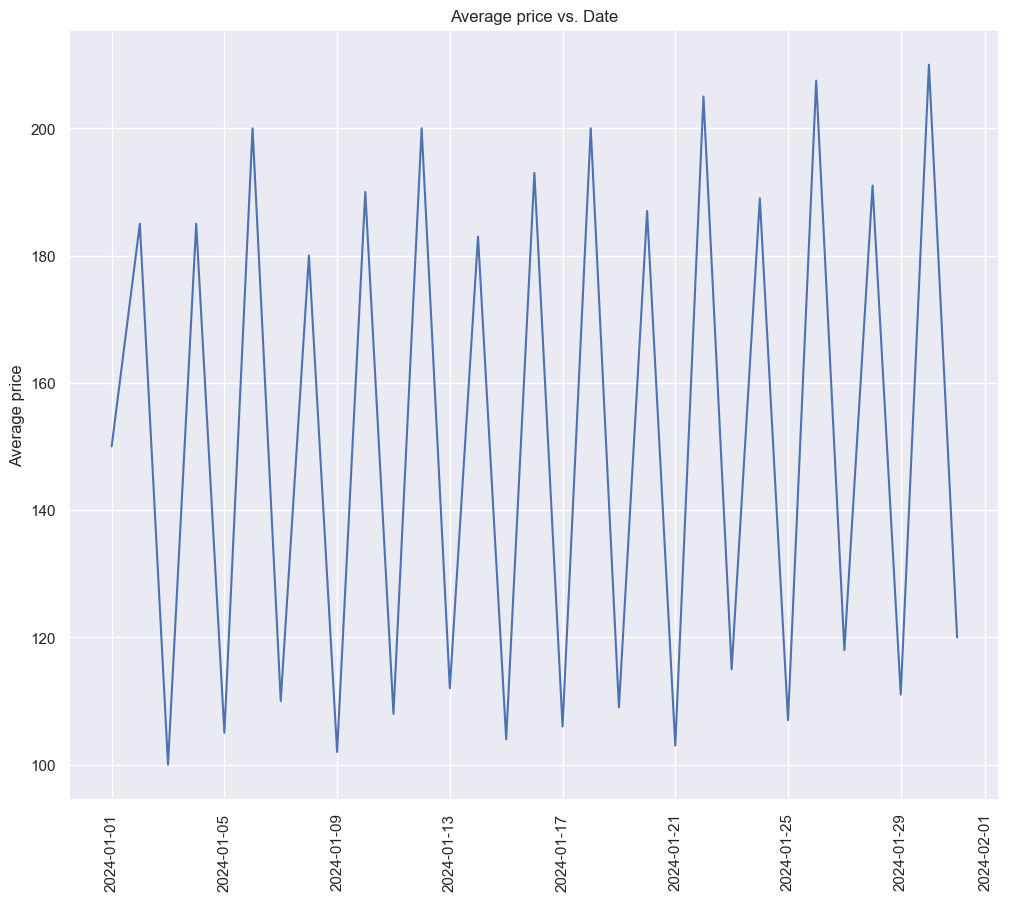

In [ ]:
plt.figure(figsize=(12,10))
plt.plot(xd,avgprice)
plt.xticks(rotation = 'vertical')
plt.ylabel('Average price')
plt.title("Average price vs. Date")
plt.show()

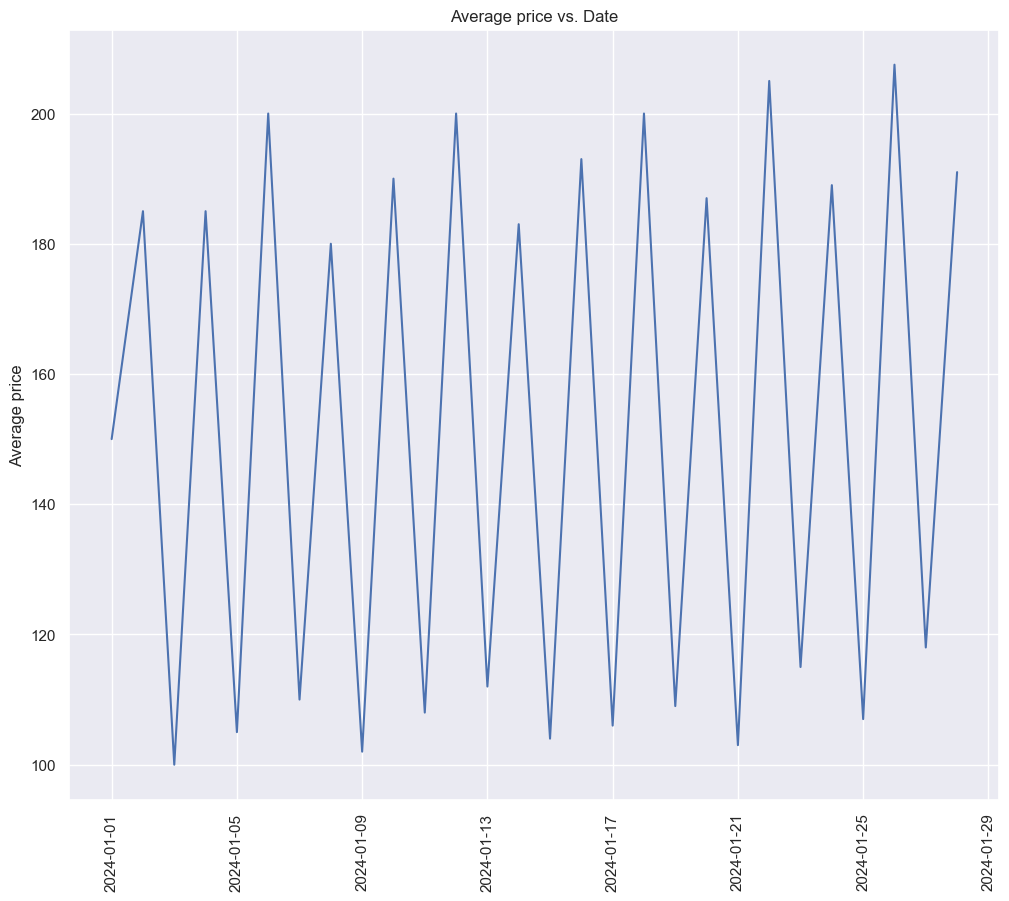

In [ ]:
#Let us also plot a smaller time interval
plt.figure(figsize=(12,10))
plt.plot(xd[0:28],avgprice[0:28])
plt.xticks(rotation = 'vertical')
plt.ylabel('Average price')
plt.title("Average price vs. Date")
plt.show()

1. There is an extremely strong cyclical component that repeats every week. This corresponds to the fact that weekend travel to NYC is very different from weekday travel.
2. There is a trend of increasing prices over time.
3. Calendar components: this is a component with sharp "spikes" that is designed to correct for any idiosyncratic elements of our calendar. This might include: (i) a monthly time series with a dip in February (since it is the shortest month); (ii) spikes in months that contain five Saturdays (since there may be more spending on weekends); or (iii) a daily time series with a dip on Labor Day (when stores are closed).

## Conclusions

In this case, we saw that Airbnb prices are influenced by many factors. Some of the main ones include location, date, number of bedrooms, number of guests, and property type.

Any future model we build should feature these factors. Incorporating some of these factors, such as the number of bedrooms, should be straightforward, as this has a large and nearly linear relationship to price. But others, such as location, exhibit very non-linear relationships. We will learn how to deal with these types of complex relationships in future cases.

We also found some surprising correlations, such as the negative correlation between price and parking. However, after breaking the data down by neighborhoods and incorporating the interaction effect of location, this negative correlation went away entirely.

Temporal effects are a very specific type of interaction effect which must be dealt with separately. Our exploration tells us that any model of AirBnB pricing should take into account strong seasonal components as well as strong spikes around major holidays. 

## Task 8 — Summary and Interpretation

Add a Markdown section that describes, in complete sentences (per project instructions):

- **What you learned from the dataset:** Price is strongly related to size (bedrooms, bathrooms, accommodates) and location (longitude/latitude and neighborhood). Correlation with price is positive for accommodates, bedrooms, and beds, and negative for longitude (more expensive listings tend to be in certain areas). Review scores and amenities (e.g. TV, AC) also show correlations but can be confounded by other factors.

- **Interesting patterns or insights:** (1) Price distributions are right-skewed with spikes at round numbers (e.g. $50, $100). (2) Parking is negatively correlated with price overall but positively within neighborhoods—a clear interaction with location. (3) Property type and number of bedrooms both matter: one-bedroom prices vary a lot by property type (e.g. room vs loft vs hotel). (4) Temporal effects (weekends, holidays like Christmas) are important for calendar pricing.

- **Limitations or assumptions:** We removed the top 1% of prices and rows with missing key columns, which may drop valid high-end listings or bias toward complete cases. Correlations do not imply causation (e.g. TV vs price). The calendar analysis uses a separate file and a single city/year, so seasonal comparisons are limited without detrending or multi-city data.

- **Anything surprising or unclear:** The negative overall correlation for parking was surprising until we conditioned on neighborhood; it highlights the need to check for confounders. The strength of the TV–price correlation is notable but may reflect listing quality rather than a direct effect of adding a TV.